# SignalScout - model results and live demos

Reads the metrics written by the training scripts (`experiments/<run>/metrics.json`), shows the plots, and runs the
same inference code the API uses: classification of example readings and a better-signal suggestion on real Cork data.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT / "backend"), str(ROOT / "ml")]
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import _plots as P
get_ipython().run_line_magic("matplotlib", "inline")
P.style()
pd.set_option("display.width", 140, "display.max_columns", 30)
print("project root:", ROOT)

from IPython.display import Image, display
summaries = {m: json.loads((ROOT / f"models/{m}.json").read_text()) for m in ("zone_classifier", "radio_estimate", "gp_signal")}
runs = {m: s["experiment"] for m, s in summaries.items()}
runs

project root: D:\abstracts\Madhav\CSDS\B\CSDS-B-B2\8.ProjectCode


{'zone_classifier': 'experiments/classifier_20260922_163745',
 'radio_estimate': 'experiments/radio_estimate_20260922_164320',
 'gp_signal': 'experiments/gp_20260922_164328'}

## 1. Radio zone classifier

In [2]:
cm = json.loads((ROOT / runs["zone_classifier"] / "metrics.json").read_text())
print("chosen:", cm["chosen"], "|", cm["chosen_by"])
rows = []
for name, r in cm["cross_validation"]["results"].items():
    rows.append({"method": name, **{p: f"{r[p]['mean']:.3f} ± {r[p]['std']:.3f}" for p in cm["profiles"]},
                 "mean": f"{r['mean_macro_f1']['mean']:.3f}"})
print("Cross-validated macro-F1 by device profile")
display(pd.DataFrame(rows).set_index("method"))
print("Held-out test macro-F1")
display(pd.DataFrame({n: {p: round(r[p]["macro_f1"], 3) for p in cm["profiles"]} for n, r in cm["test"].items()}).T)

chosen: PyTorch MLP | best cross-validated mean macro-F1 across device profiles
Cross-validated macro-F1 by device profile


,full,no_sinr_cqi,level_only,rssi_only,mean
method,,,,,
Random Forest,1.000 ± 0.000,0.836 ± 0.039,0.678 ± 0.059,0.609 ± 0.044,0.781
XGBoost,1.000 ± 0.000,0.835 ± 0.036,0.681 ± 0.056,0.620 ± 0.042,0.784
PyTorch MLP,1.000 ± 0.000,0.838 ± 0.034,0.688 ± 0.055,0.619 ± 0.056,0.786
Ranges on reported metrics,1.000 ± 0.000,0.698 ± 0.080,0.692 ± 0.079,0.185 ± 0.019,0.644
Tuned single threshold,0.674 ± 0.047,0.674 ± 0.047,0.674 ± 0.047,0.635 ± 0.049,0.664


Held-out test macro-F1


,full,no_sinr_cqi,level_only,rssi_only
Random Forest,1.000,0.859,0.712,0.664
XGBoost,1.000,0.857,0.703,0.684
PyTorch MLP,1.000,0.861,0.726,0.691
Ranges on reported metrics,1.000,0.742,0.739,0.184
Tuned single threshold,0.729,0.729,0.727,0.699


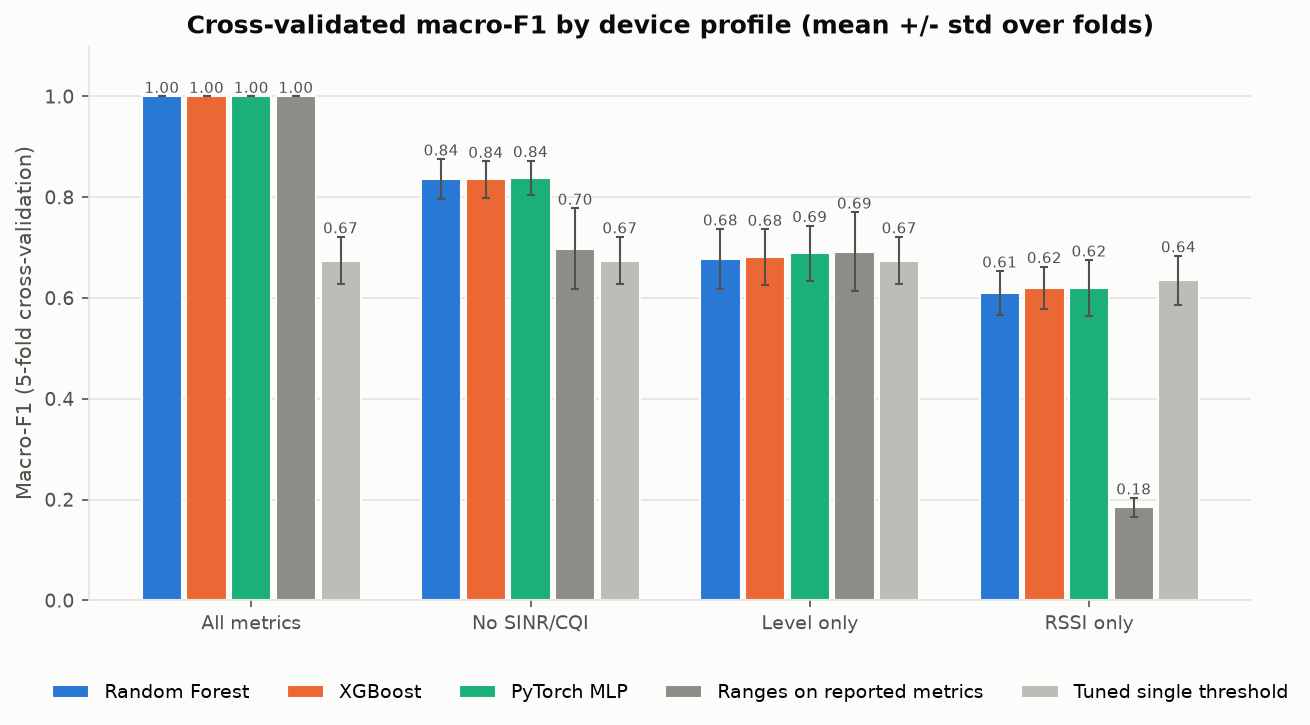

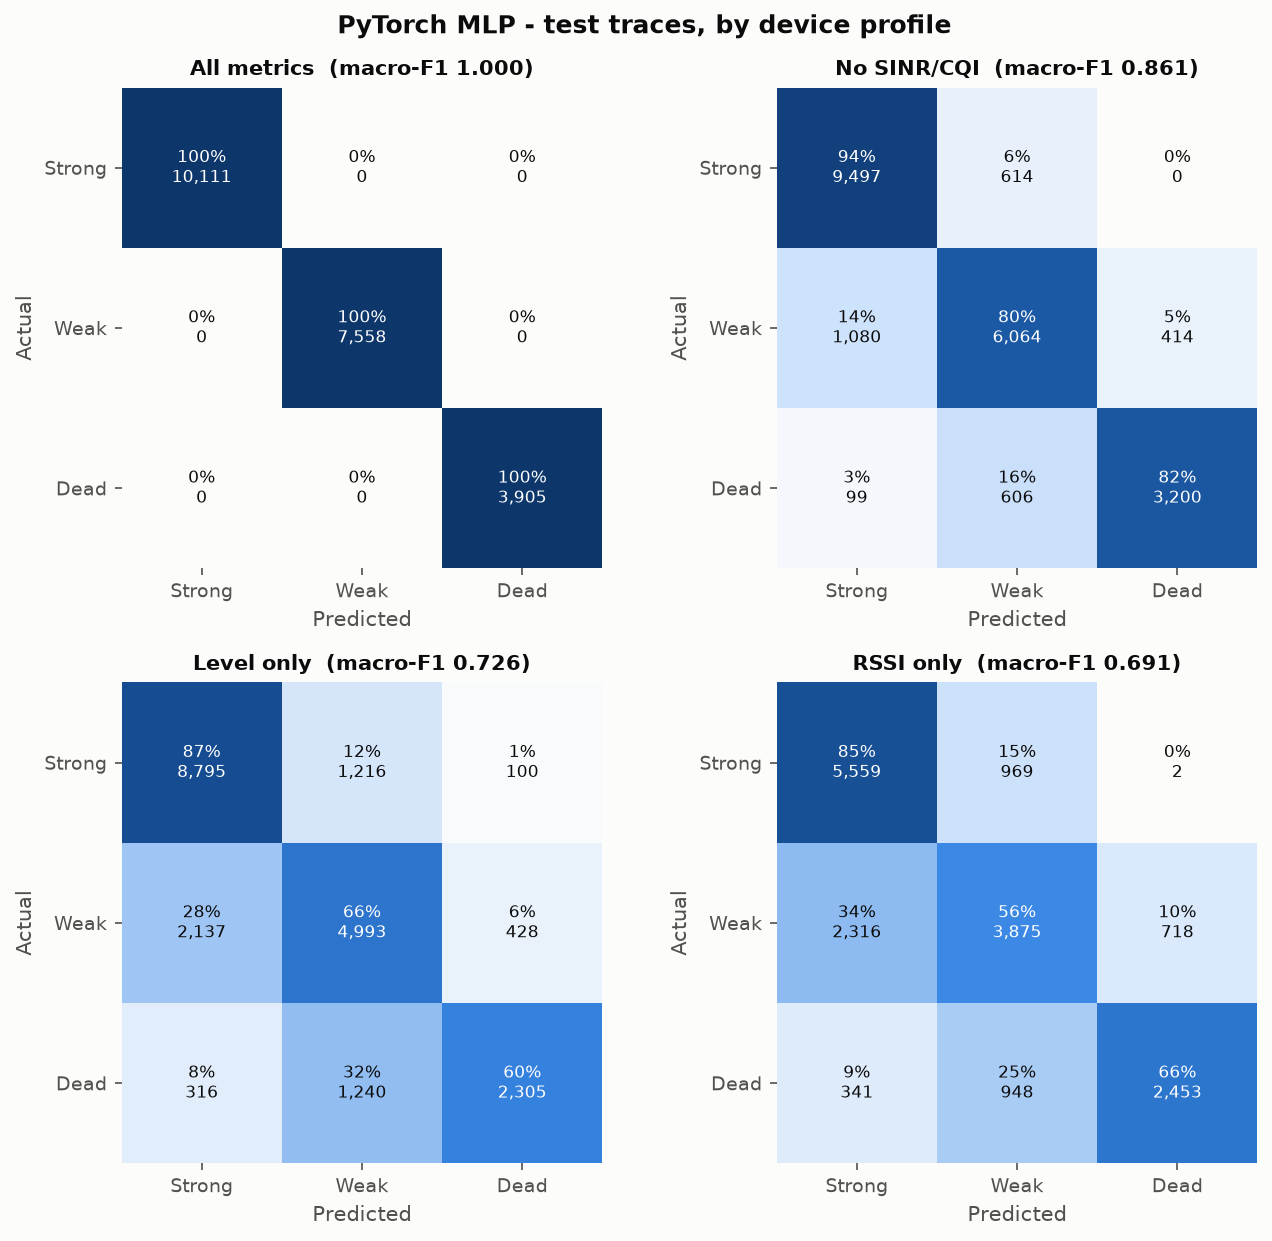

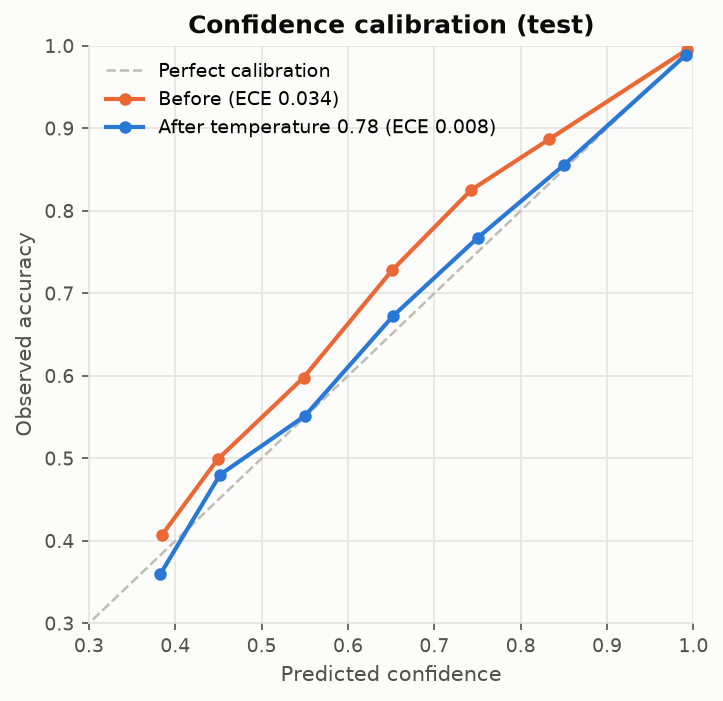

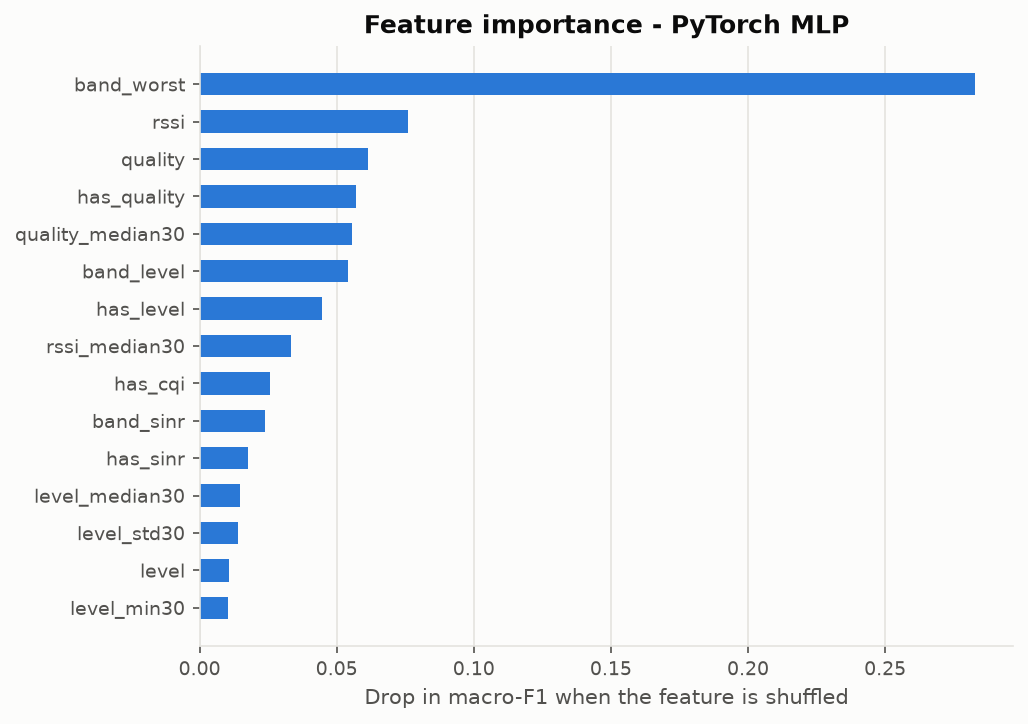

In [3]:
for png in ("cv_profile_scores.png", "confusion_matrix.png", "calibration.png", "feature_importance.png"):
    display(Image(filename=str(ROOT / runs["zone_classifier"] / png), width=720))

## 2. Radio-condition estimate from speed tests (phone probe)

per speed test: {'accuracy': 0.493, 'macro_f1': 0.498}
per zone      : {'zones': 52, 'accuracy': 0.5576923076923077, 'macro_f1': 0.5388007054673721}
baselines     : {'always_majority': 0.211, 'tuned_speed_threshold': 0.466}


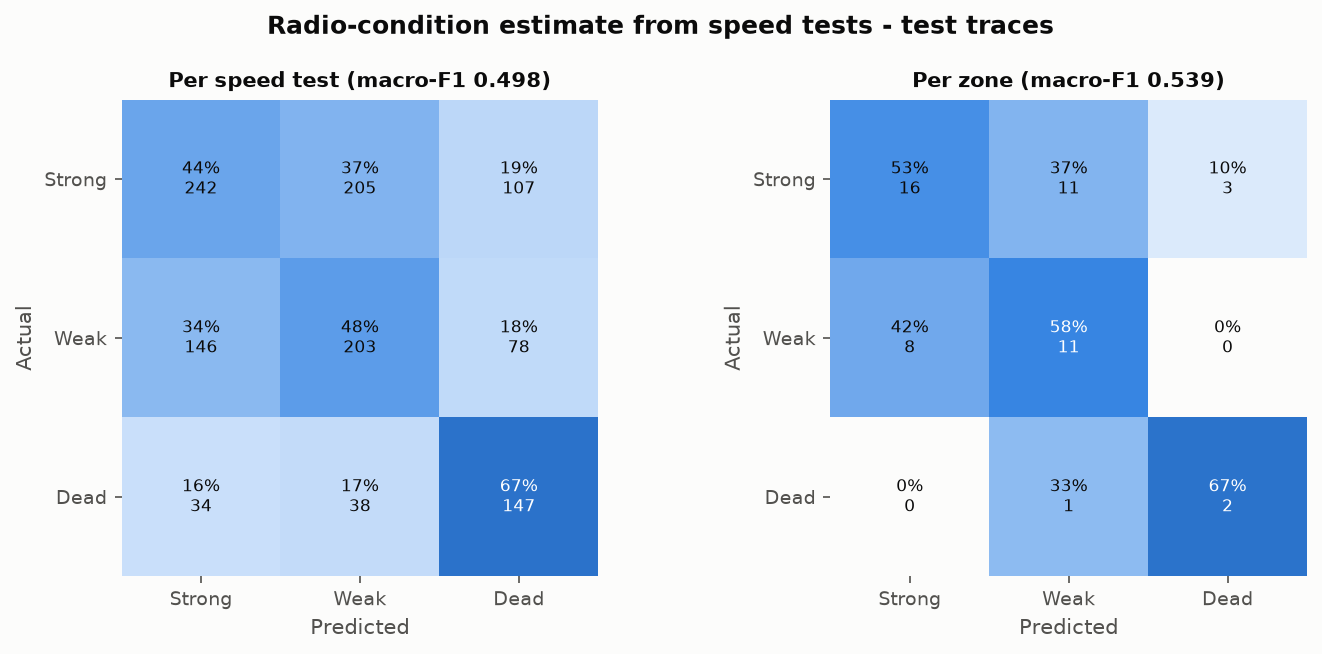

In [4]:
rm = json.loads((ROOT / runs["radio_estimate"] / "metrics.json").read_text())
print("per speed test:", {k: round(rm["test_per_speed_test"][k], 3) for k in ("accuracy", "macro_f1")})
print("per zone      :", {k: rm["test_per_zone"].get(k) for k in ("zones", "accuracy", "macro_f1")})
print("baselines     :", {k: round(v["macro_f1"], 3) for k, v in rm["baselines"].items()})
display(Image(filename=str(ROOT / runs["radio_estimate"] / "confusion_matrix.png"), width=720))

## 3. Gaussian Process better-signal model

,rsrp,log_dl
Gaussian Process,6.341,0.430
Inverse distance,6.825,0.441
Nearest neighbours,7.427,0.451
Local mean,10.948,0.560
Area mean,10.972,0.567


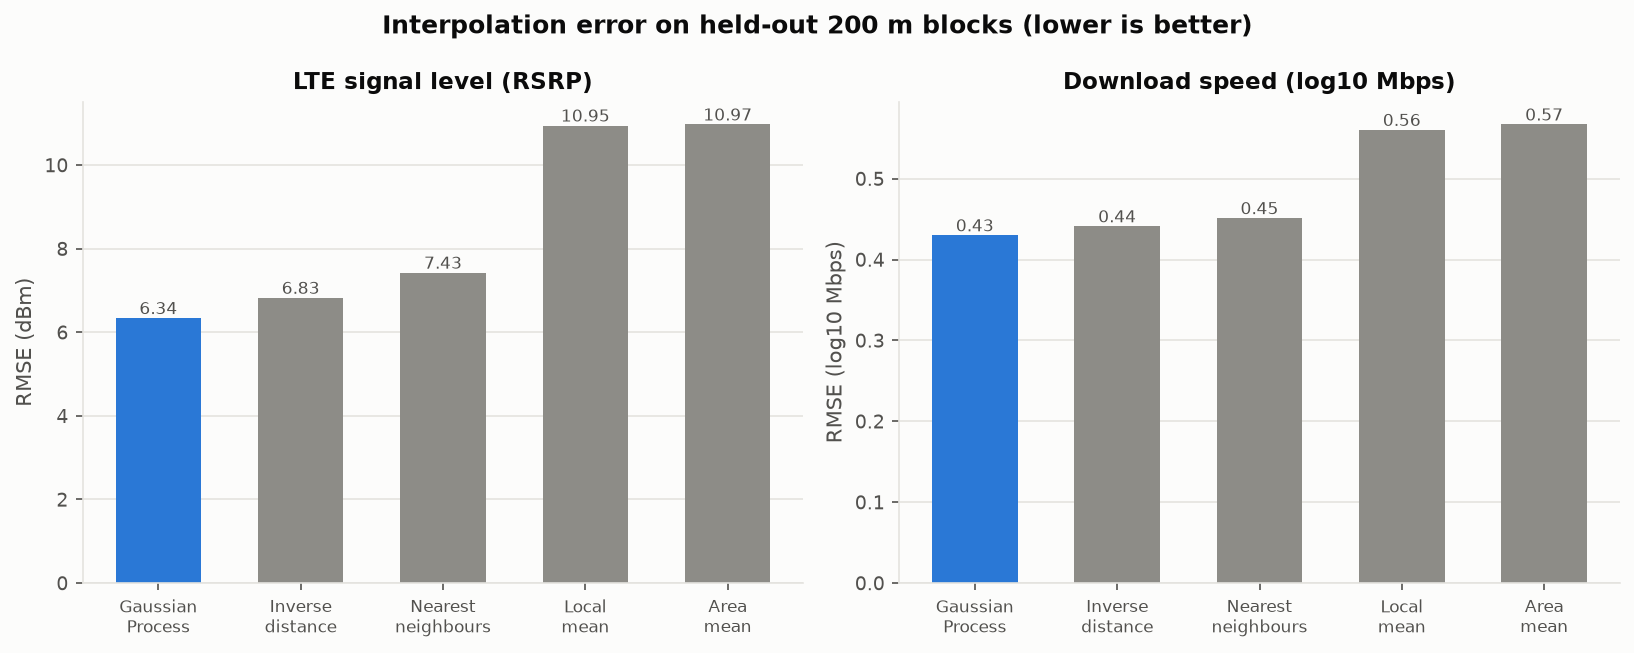

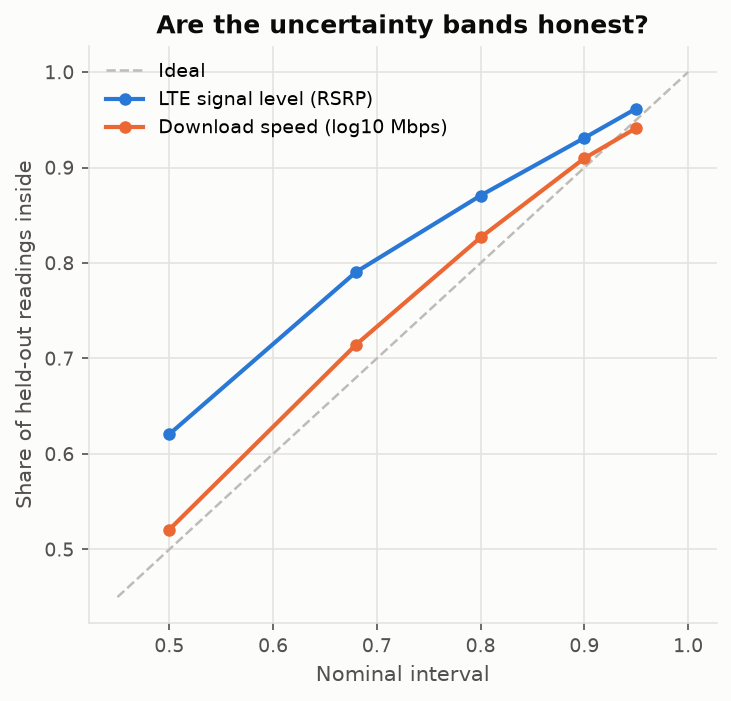

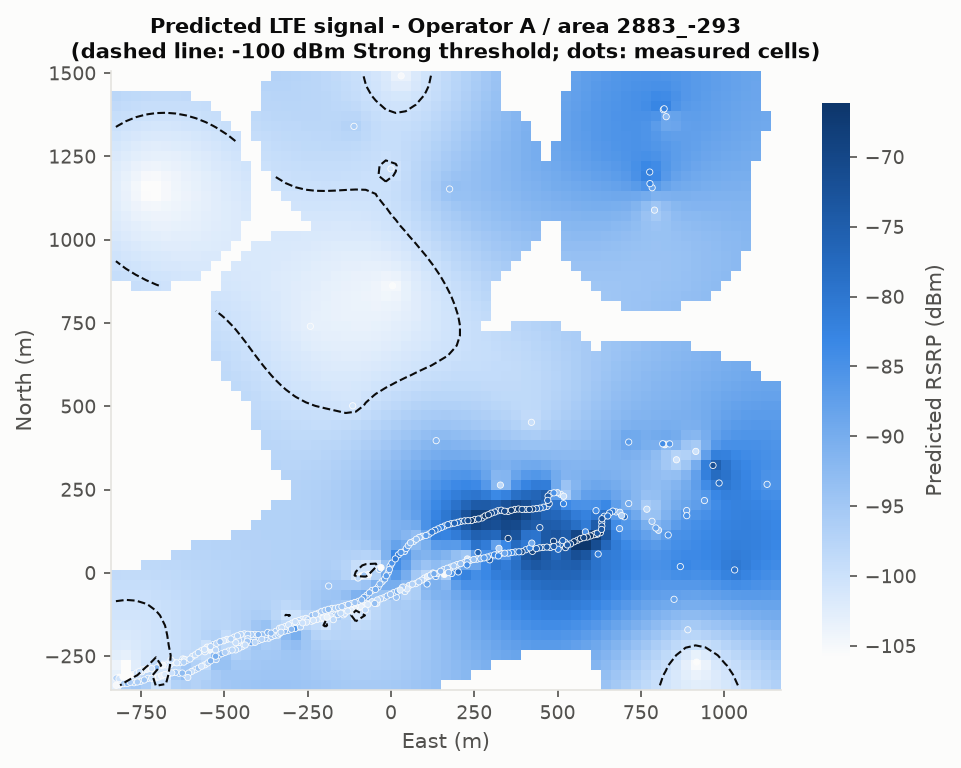

In [5]:
gm = json.loads((ROOT / runs["gp_signal"] / "metrics.json").read_text())
display(pd.DataFrame({t: {m: round(v["rmse"], 3) for m, v in r["block_cv_summary"].items()} for t, r in gm["targets"].items()}))
for png in ("rmse_comparison.png", "interval_calibration.png", "surface_rsrp.png"):
    display(Image(filename=str(ROOT / runs["gp_signal"] / png), width=720))

## 4. Live demo - the code the API runs

In [6]:
from app.ml.service import ModelService
svc = ModelService(ROOT / "models")
frame = pd.DataFrame({
    "device_key": ["demo"] * 4, "ts": pd.date_range("2026-09-01 10:00", periods=4, freq="5s"),
    "network_type": ["LTE", "LTE", "LTE", "HSPA+"],
    "rsrp": [-82, -109, -121, -99], "rsrq": [-9, -12, np.nan, -7], "sinr": [17, 3, np.nan, np.nan],
    "rssi": [-58, -80, np.nan, np.nan], "cqi": [12, 6, np.nan, np.nan], "in_service": True})
for (_, r), v in zip(frame.iterrows(), svc.classify_radio(frame)):
    print(f"{r.network_type:6s} RSRP {r.rsrp:5.0f} -> {v.label:6s} {v.confidence:.2f} | {v.reasons[0]}")

LTE    RSRP   -82 -> Strong 1.00 | RSRP -82 dBm is at or above -100 dBm
LTE    RSRP  -109 -> Weak   1.00 | RSRP -109 dBm is below -100 dBm
LTE    RSRP  -121 -> Dead   1.00 | RSRP -121 dBm is below -115 dBm
HSPA+  RSRP   -99 -> Weak   1.00 | RSCP -99 dBm is below -95 dBm


user at 51.89275 -8.50221 measured -108.0 dBm
Better signal about 168 m NE (predicted -98 dBm, 87% likely Strong).


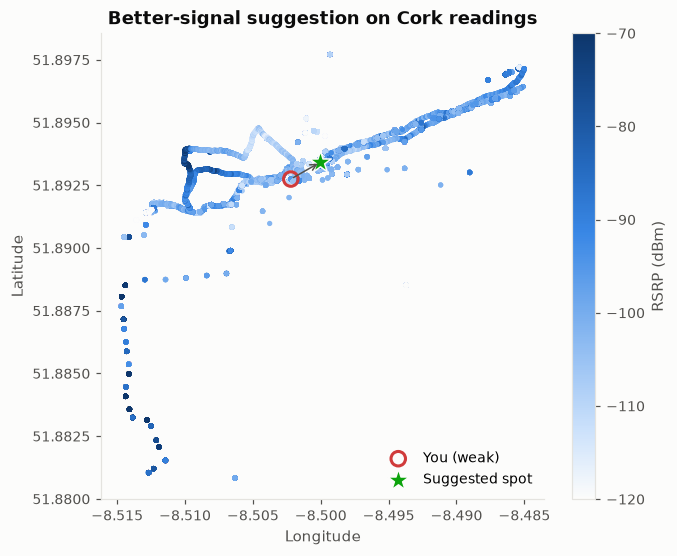

In [7]:
from app.ml.suggest import suggest
lte = pd.read_csv(ROOT / "data/processed/lte_speed_clean.csv.gz", parse_dates=["ts"])
pts = lte[(lte.family == "lte_nr") & (lte.operator == "Operator A")]
center = pts[["lat", "lon"]].round(2).value_counts().index[0]
area = pts[(pts.lat.sub(center[0]).abs() < 0.01) & (pts.lon.sub(center[1]).abs() < 0.015)]
weak = area[area.label > 0].iloc[len(area[area.label > 0]) // 2]
s = suggest(svc.gp, "rsrp", weak.lat, weak.lon, area.lat, area.lon, area["level"], operator="Operator A")
print("user at", round(weak.lat, 5), round(weak.lon, 5), "measured", weak["level"], "dBm")
print(s.message)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(area.lon, area.lat, c=area["level"], cmap=P.BLUES, s=6, vmin=-120, vmax=-70)
ax.scatter([weak.lon], [weak.lat], marker="o", s=90, facecolors="none", edgecolors=P.STATUS["Dead"], linewidths=2, label="You (weak)")
if s.found and s.lat is not None:
    ax.scatter([s.lon], [s.lat], marker="*", s=220, color=P.STATUS["Strong"], edgecolors=P.SURFACE, label="Suggested spot")
    ax.annotate("", xy=(s.lon, s.lat), xytext=(weak.lon, weak.lat), arrowprops=dict(arrowstyle="->", color=P.TEXT_2))
ax.set_title("Better-signal suggestion on Cork readings"); ax.legend(loc="lower right"); fig.colorbar(sc, label="RSRP (dBm)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.grid(False)
plt.show()